<a href="https://colab.research.google.com/github/YAshhh29/Algorithms/blob/main/K_MEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


════════════════════════════════════════════════════════════════
  Qn-1 · WHAT IS PRE-PROCESSING?
────────────────────────────────────────────────────────────────
  K-Means measures how "close" two students are using
  Euclidean distance.  If we feed in raw numbers:
  
      study_hours   →  range  1–9
      attendance    →  range  50–99
      previous_grade → range  40–99
  
  'attendance' and 'previous_grade' will DOMINATE the
  distance just because their numbers are larger.
  A 1-point difference in grade would outweigh a full
  extra hour of study — which makes no sense.
  
  FIX → Min-Max Normalisation:
      x_norm = (x − x_min) / (x_max − x_min)
  
  This squashes every feature to [0, 1].
  Now all three features vote EQUALLY in the distance.
════════════════════════════════════════════════════════════════



Saving student_performance_4000-2.csv to student_performance_4000-2 (2).csv
Dataset loaded: (4000, 7)

Raw feature ranges:
     study_hours  attendance  previous_grade
min            1          50              40
max            9          99              99

After normalisation (all columns must be 0–1):
     study_hours  attendance  previous_grade
min          0.0         0.0             0.0
max          1.0         1.0             1.0

════════════════════════════════════════════════════════════════
  Qn-2 · WHAT IS A CENTROID AND HOW DO WE START?
────────────────────────────────────────────────────────────────
  A centroid = the "centre point" of a cluster.
  Before we know which students belong together, we
  need K starting guesses.
  
  STRATEGY (Random Init):
    Pick K actual student rows from the dataset at random.
  
  WHY use real rows and not random numbers?
    Random numbers in [0,1] might place a centroid in an
    empty region.  Real rows guarantee centroids start
    i

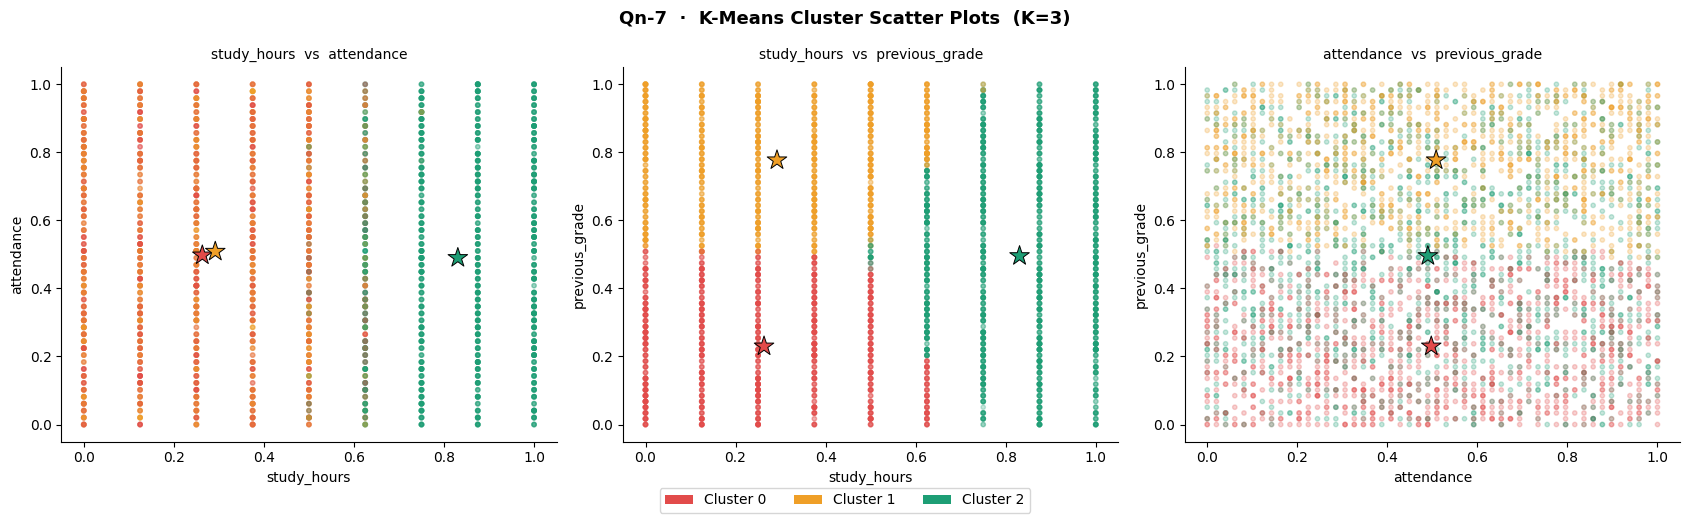

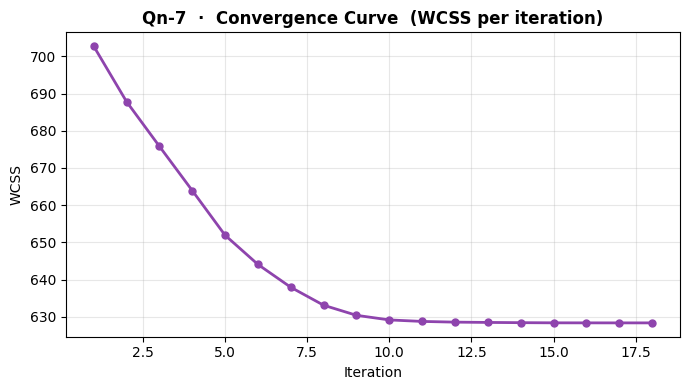


════════════════════════════════════════════════════════════════
  Qn-8 · HOW DO WE CHOOSE THE BEST K?
────────────────────────────────────────────────────────────────
  Problem: We assumed K=3, but how do we JUSTIFY that?
  
  ELBOW METHOD:
    Run K-Means for K = 1, 2, 3, … 10.
    Record final WCSS for each K.
    Plot WCSS vs K.
  
  What the curve looks like:
    K=1 → very high WCSS (everyone in one cluster)
    K=2 → big drop
    K=3 → another big drop          ← ELBOW here
    K=4 → smaller drop
    K=5+ → diminishing returns
  
  The "elbow" is where adding one more cluster stops
  giving meaningful improvement.  That K is optimal.
  
  For this dataset the elbow appears at K=3, confirming
  High / Average / Low is the natural structure.
════════════════════════════════════════════════════════════════

Running Elbow Method …
  ✔ Converged in 2 iterations  (shift = 0.00e+00)
  K= 1  WCSS=1102.87
  ✔ Converged in 27 iterations  (shift = 0.00e+00)
  K= 2  WCSS=788.56
  ✔ Converg

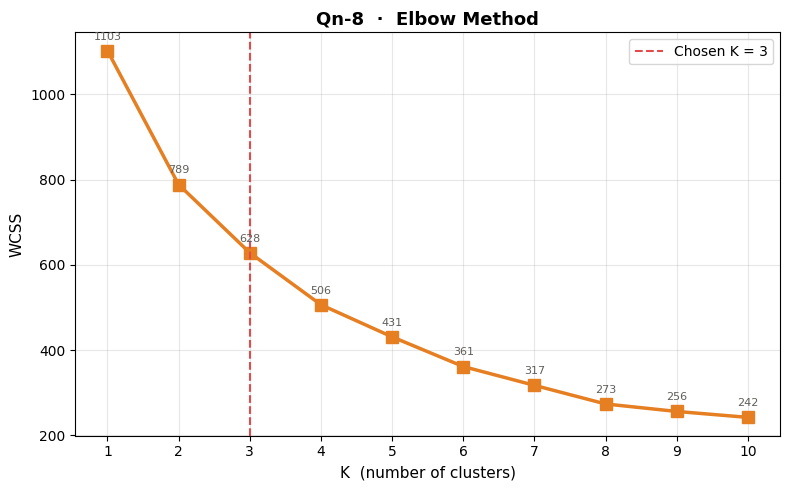


════════════════════════════════════════════════════════════════
  Qn-9 · HOW DO WE INTERPRET THE CLUSTERS?
────────────────────────────────────────────────────────────────
  Up to this point K-Means only produced numbers:
    Cluster 0, Cluster 1, Cluster 2.
  
  It has NO idea what "High Performer" means.
  
  Now we bring in 'performance_score' (which we
  deliberately kept hidden during clustering).
  
  WHY keep it hidden?
    K-Means is UNSUPERVISED.  Using the score would be
    "cheating" — we'd be clustering WITH the answer.
  
  NOW we use it as a validator:
    Average performance_score per cluster:
      Highest average → label it "High Performers"
      Lowest  average → label it "Low Performers"
      Middle          → "Average Performers"
  
  This is how unsupervised results get real-world meaning.
════════════════════════════════════════════════════════════════

CLUSTER ANALYSIS
────────────────────────────────────────────────────────────
                      label  

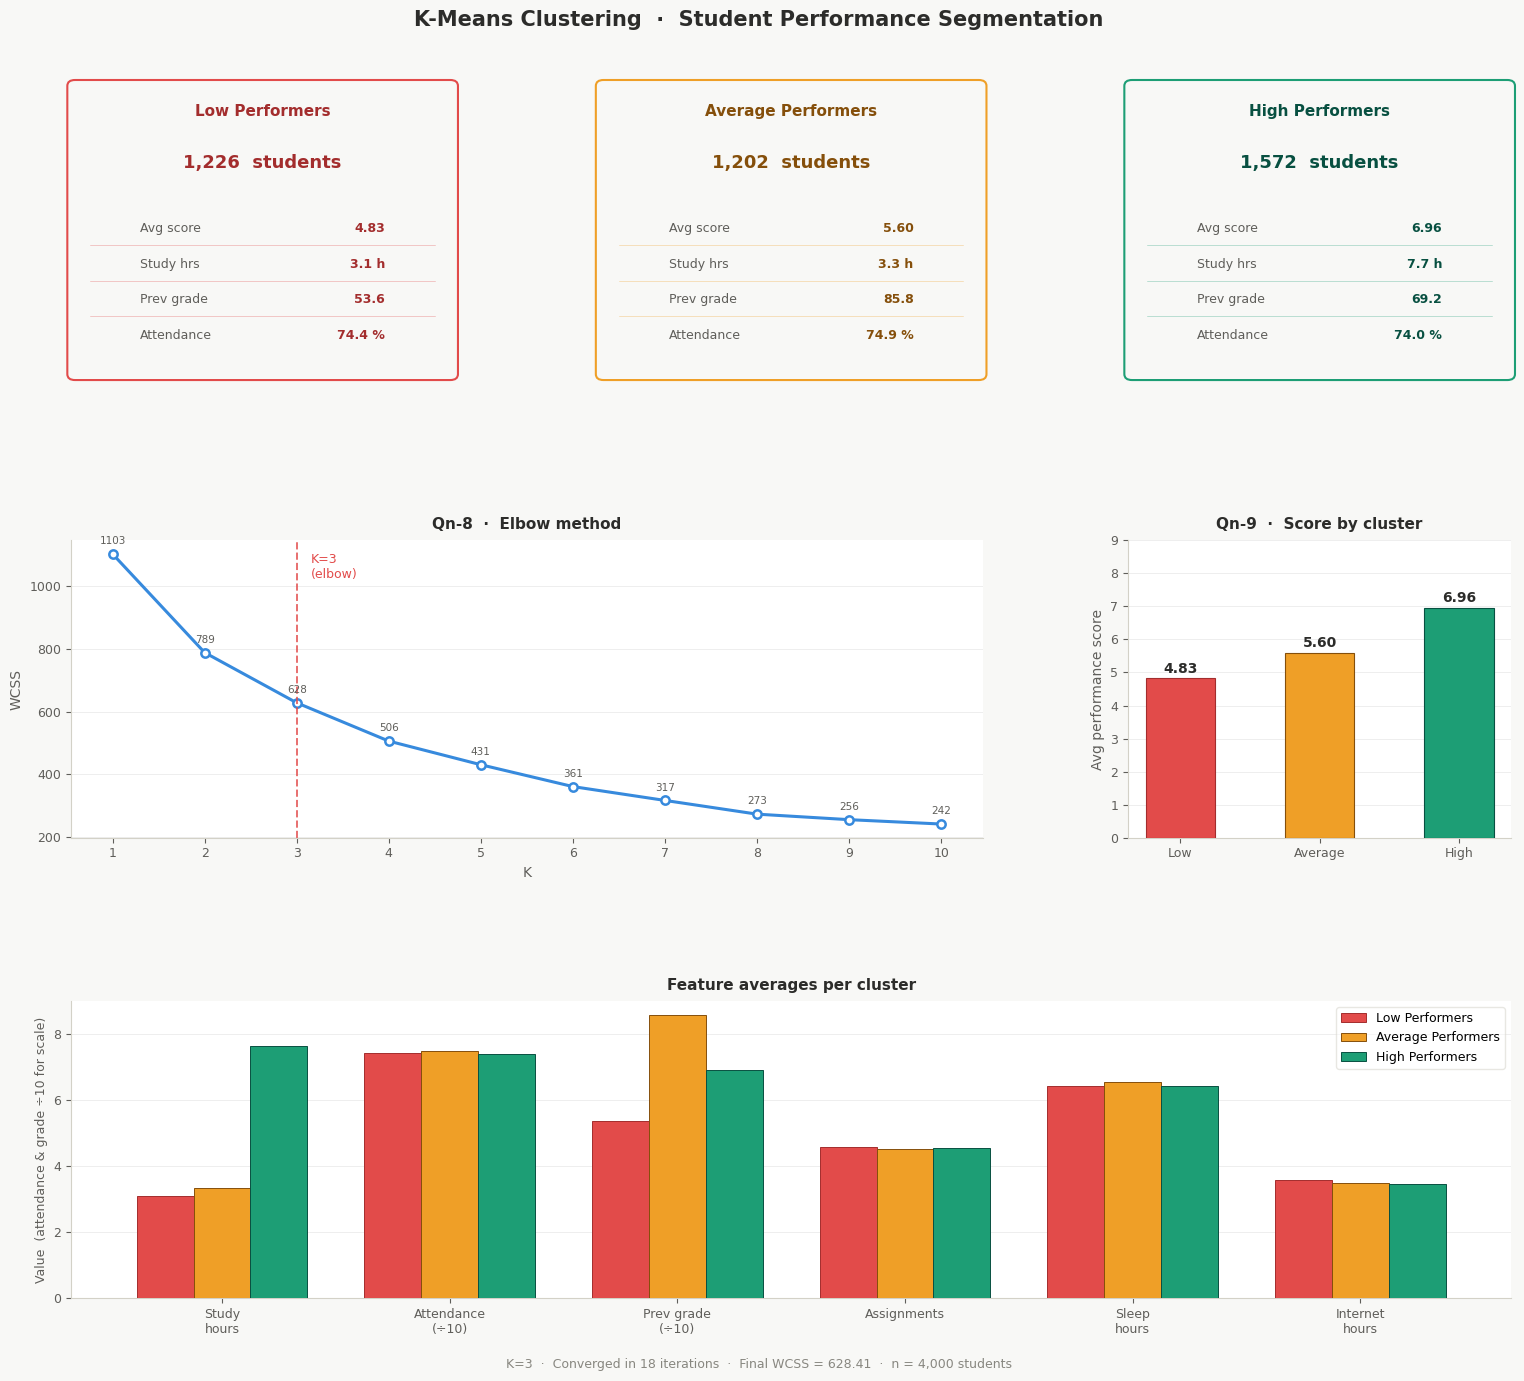

Saved: kmeans_dashboard.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅  All done!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
#   K-MEANS CLUSTERING FROM SCRATCH  |  AIML Lab
#   Single file — run top to bottom in Google Colab
#   Contains: full algorithm + explanations + results dashboard
# ╚══════════════════════════════════════════════════════════════╝

# ── CELL 0 : Imports ─────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from google.colab import files

def section(title, body):
    """Print a formatted explanation box."""
    w = 64
    print("\n" + "═" * w)
    print(f"  {title}")
    print("─" * w)
    for line in body.strip().split("\n"):
        print(f"  {line}")
    print("═" * w + "\n")


# ══════════════════════════════════════════════════════════════
# CELL 1 · Qn-1 : DATA PRE-PROCESSING
# ══════════════════════════════════════════════════════════════
section("Qn-1 · WHAT IS PRE-PROCESSING?", """
K-Means measures how "close" two students are using
Euclidean distance.  If we feed in raw numbers:

    study_hours   →  range  1–9
    attendance    →  range  50–99
    previous_grade → range  40–99

'attendance' and 'previous_grade' will DOMINATE the
distance just because their numbers are larger.
A 1-point difference in grade would outweigh a full
extra hour of study — which makes no sense.

FIX → Min-Max Normalisation:
    x_norm = (x − x_min) / (x_max − x_min)

This squashes every feature to [0, 1].
Now all three features vote EQUALLY in the distance.
""")

uploaded  = files.upload()
csv_name  = list(uploaded.keys())[0]
df        = pd.read_csv(csv_name)

FEATURES  = ['study_hours', 'attendance', 'previous_grade']
X_raw     = df[FEATURES].values          # (4000, 3)

def minmax_normalize(X):
    x_min  = X.min(axis=0)
    x_max  = X.max(axis=0)
    return (X - x_min) / (x_max - x_min), x_min, x_max

X, x_min, x_max = minmax_normalize(X_raw)

print("Dataset loaded:", df.shape)
print("\nRaw feature ranges:")
print(df[FEATURES].agg(['min','max']).round(1).to_string())
print("\nAfter normalisation (all columns must be 0–1):")
print(pd.DataFrame(X, columns=FEATURES).agg(['min','max']).round(3).to_string())


# ══════════════════════════════════════════════════════════════
# CELL 2 · Qn-2 : INITIALISE CENTROIDS
# ══════════════════════════════════════════════════════════════
section("Qn-2 · WHAT IS A CENTROID AND HOW DO WE START?", """
A centroid = the "centre point" of a cluster.
Before we know which students belong together, we
need K starting guesses.

STRATEGY (Random Init):
  Pick K actual student rows from the dataset at random.

WHY use real rows and not random numbers?
  Random numbers in [0,1] might place a centroid in an
  empty region.  Real rows guarantee centroids start
  inside the data cloud → faster convergence.

We will use K = 3:
  Cluster A → High Performers
  Cluster B → Average Performers
  Cluster C → Low Performers
(the algorithm decides which is which — we label LATER)
""")

K = 3

def initialize_centroids(X, k, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=k, replace=False)
    return X[idx].copy()

centroids_init = initialize_centroids(X, K)
print("Initial centroids (normalised space):")
print(pd.DataFrame(centroids_init, columns=FEATURES).round(4).to_string())


# ══════════════════════════════════════════════════════════════
# CELL 3 · Qn-3 : CLUSTER ASSIGNMENT
# ══════════════════════════════════════════════════════════════
section("Qn-3 · HOW DO WE ASSIGN STUDENTS TO CLUSTERS?", """
For every student we ask:
  "Which centroid am I closest to?"

We compute Euclidean distance to all K centroids:

  d(x, c) = √[ (sh_x−sh_c)² + (att_x−att_c)² + (pg_x−pg_c)² ]

The student is assigned to the NEAREST centroid.

INTUITION: Picture students as dots in 3-D space.
The 3 centroids are magnets.  Each dot snaps to its
closest magnet.

IMPLEMENTATION: We avoid a slow Python loop over 4000
students by using NumPy broadcasting — all distances
are computed in one vectorised operation.
""")

def compute_distances(X, centroids):
    # X[:, None, :] shape (n,1,d)  −  centroids[None,:,:] shape (1,k,d)
    # difference broadcasts to (n, k, d)
    diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))          # → (n, k)

def assign_clusters(X, centroids):
    return np.argmin(compute_distances(X, centroids), axis=1)

labels_demo = assign_clusters(X, centroids_init)
print("Students per cluster after first assignment:")
for u, c in zip(*np.unique(labels_demo, return_counts=True)):
    print(f"  Cluster {u}: {c:,} students")


# ══════════════════════════════════════════════════════════════
# CELL 4 · Qn-4 : UPDATE CENTROIDS
# ══════════════════════════════════════════════════════════════
section("Qn-4 · HOW DO CENTROIDS MOVE?", """
After every student is assigned, the centroid moves to
the MEAN of all students in that cluster:

  new_centroid_j = (1/|Cⱼ|) Σ_{x ∈ Cⱼ} x

Example:
  Cluster 0 has 1,400 students.
  New centroid = average study_hours, attendance,
                 previous_grade of those 1,400 students.

The centroid physically "travels" towards the centre
of its group.  Next iteration, students re-evaluate
which centroid they are closest to — some will switch.

EDGE CASE: If a cluster becomes empty, we reinitialise
its centroid to a random data point.
""")

def update_centroids(X, labels, k):
    new_c = np.zeros((k, X.shape[1]))
    for j in range(k):
        members = X[labels == j]
        new_c[j] = members.mean(axis=0) if len(members) > 0 \
                   else X[np.random.randint(len(X))]
    return new_c

centroids_updated = update_centroids(X, labels_demo, K)
print("Centroids after first move:")
print(pd.DataFrame(centroids_updated, columns=FEATURES).round(4).to_string())


# ══════════════════════════════════════════════════════════════
# CELL 5 · Qn-6 : WCSS  (defined before the loop needs it)
# ══════════════════════════════════════════════════════════════
section("Qn-6 · WHAT IS WCSS AND WHY DO WE TRACK IT?", """
WCSS = Within-Cluster Sum of Squares

  WCSS = Σⱼ  Σ_{x ∈ Cⱼ}  ‖x − centroid_j‖²

It answers: "How far, in total, are all students
from their own cluster centre?"

Lower WCSS = tighter, more compact clusters = better.

We track WCSS after every iteration.
Expected behaviour:
  Iteration 1 → high WCSS (centroids are far from their groups)
  Iteration 2 → drops sharply
  …
  Iteration N → barely changes → CONVERGENCE

WCSS is also used in the Elbow Method (Qn-8) to
decide the best value of K.
""")

def compute_wcss(X, labels, centroids):
    total = 0.0
    for j in range(len(centroids)):
        members = X[labels == j]
        if len(members) > 0:
            total += ((members - centroids[j]) ** 2).sum()
    return total


# ══════════════════════════════════════════════════════════════
# CELL 6 · Qn-5 : FULL ITERATION LOOP
# ══════════════════════════════════════════════════════════════
section("Qn-5 · THE LOOP — ASSIGN → UPDATE → REPEAT", """
The full K-Means algorithm:

  1. Initialise K centroids           (done in Qn-2)
  ┌─────────────────────────────────┐
  │  2. ASSIGN each point to        │
  │     nearest centroid  (Qn-3)    │
  │  3. UPDATE centroids to mean    │
  │     of their members  (Qn-4)    │
  │  4. Measure centroid shift      │
  └────────── REPEAT ───────────────┘
  5. STOP when shift < tolerance

CONVERGENCE GUARANTEE:
  Every iteration either REDUCES or MAINTAINS WCSS.
  It can never go back up.  Since WCSS ≥ 0, the loop
  is mathematically guaranteed to stop.

We also add max_iter = 300 as a safety cap.
""")

def kmeans(X, k, seed=42, max_iter=300, tol=1e-6):
    centroids = initialize_centroids(X, k, seed)
    history   = []
    for i in range(max_iter):
        labels        = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        history.append(compute_wcss(X, labels, new_centroids))
        shift         = np.max(np.linalg.norm(new_centroids - centroids, axis=1))
        centroids     = new_centroids
        if shift < tol:
            print(f"  ✔ Converged in {i+1} iterations  (shift = {shift:.2e})")
            return labels, centroids, history, i + 1
    print(f"  ⚠ Reached max_iter={max_iter}")
    return labels, centroids, history, max_iter

print("Running K-Means  (K=3) …")
labels, centroids, wcss_history, n_iters = kmeans(X, K)
print(f"\n  Final WCSS : {wcss_history[-1]:.4f}")
print(f"  Cluster sizes:")
for j in range(K):
    print(f"    Cluster {j}: {(labels==j).sum():,} students")


# ══════════════════════════════════════════════════════════════
# CELL 7 · Qn-7 : SCATTER PLOTS + CONVERGENCE CURVE
# ══════════════════════════════════════════════════════════════
section("Qn-7 · VISUALISING THE CLUSTERS", """
We have 3 features → we cannot show them all in one 2-D
plot.  Solution: plot 2 features at a time (3 pairs).

Each colour = one cluster.  ★ = centroid position.

The tighter each colour cloud is around its ★,
the better the clustering.

We also plot WCSS vs iteration to verify convergence —
the curve should drop steeply then flatten.
""")

COLORS = ['#E24B4A', '#EF9F27', '#1D9E75']
CMAP   = [COLORS[l] for l in labels]
pairs  = [(0,1),(0,2),(1,2)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Qn-7  ·  K-Means Cluster Scatter Plots  (K=3)",
             fontsize=13, fontweight='bold')

for ax, (i, j) in zip(axes, pairs):
    ax.scatter(X[:,i], X[:,j], c=CMAP, alpha=0.25, s=10)
    ax.scatter(centroids[:,i], centroids[:,j],
               c=COLORS, s=220, marker='*',
               edgecolors='black', linewidths=0.7, zorder=5)
    ax.set_xlabel(FEATURES[i], fontsize=10)
    ax.set_ylabel(FEATURES[j], fontsize=10)
    ax.set_title(f"{FEATURES[i]}  vs  {FEATURES[j]}", fontsize=10)
    ax.spines[['top','right']].set_visible(False)

legend_els = [mpatches.Patch(facecolor=COLORS[j],
              label=f"Cluster {j}") for j in range(K)]
fig.legend(handles=legend_els, loc='lower center',
           ncol=K, fontsize=10, bbox_to_anchor=(0.5,-0.04))
plt.tight_layout()
plt.savefig("clusters_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

# Convergence curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(wcss_history)+1), wcss_history,
         'o-', color='#8E44AD', linewidth=2, markersize=5)
plt.xlabel("Iteration"); plt.ylabel("WCSS")
plt.title("Qn-7  ·  Convergence Curve  (WCSS per iteration)",
          fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("convergence_curve.png", dpi=150)
plt.show()


# ══════════════════════════════════════════════════════════════
# CELL 8 · Qn-8 : ELBOW METHOD
# ══════════════════════════════════════════════════════════════
section("Qn-8 · HOW DO WE CHOOSE THE BEST K?", """
Problem: We assumed K=3, but how do we JUSTIFY that?

ELBOW METHOD:
  Run K-Means for K = 1, 2, 3, … 10.
  Record final WCSS for each K.
  Plot WCSS vs K.

What the curve looks like:
  K=1 → very high WCSS (everyone in one cluster)
  K=2 → big drop
  K=3 → another big drop          ← ELBOW here
  K=4 → smaller drop
  K=5+ → diminishing returns

The "elbow" is where adding one more cluster stops
giving meaningful improvement.  That K is optimal.

For this dataset the elbow appears at K=3, confirming
High / Average / Low is the natural structure.
""")

K_range    = range(1, 11)
wcss_elbow = []
print("Running Elbow Method …")
for k in K_range:
    _, _, hist, _ = kmeans(X, k, seed=42)
    wcss_elbow.append(hist[-1])
    print(f"  K={k:2d}  WCSS={hist[-1]:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), wcss_elbow, 's-', color='#E67E22',
         linewidth=2.5, markersize=8)
for k, w in zip(K_range, wcss_elbow):
    plt.annotate(f"{w:.0f}", (k, w),
                 textcoords='offset points', xytext=(0,8),
                 ha='center', fontsize=8, color='#5F5E5A')
plt.axvline(x=3, color='#E24B4A', linestyle='--',
            linewidth=1.5, label='Chosen K = 3')
plt.xticks(list(K_range))
plt.xlabel("K  (number of clusters)", fontsize=11)
plt.ylabel("WCSS", fontsize=11)
plt.title("Qn-8  ·  Elbow Method", fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150)
plt.show()


# ══════════════════════════════════════════════════════════════
# CELL 9 · Qn-9 : ANALYSIS
# ══════════════════════════════════════════════════════════════
section("Qn-9 · HOW DO WE INTERPRET THE CLUSTERS?", """
Up to this point K-Means only produced numbers:
  Cluster 0, Cluster 1, Cluster 2.

It has NO idea what "High Performer" means.

Now we bring in 'performance_score' (which we
deliberately kept hidden during clustering).

WHY keep it hidden?
  K-Means is UNSUPERVISED.  Using the score would be
  "cheating" — we'd be clustering WITH the answer.

NOW we use it as a validator:
  Average performance_score per cluster:
    Highest average → label it "High Performers"
    Lowest  average → label it "Low Performers"
    Middle          → "Average Performers"

This is how unsupervised results get real-world meaning.
""")

df['cluster'] = labels
centroids_orig = centroids * (x_max - x_min) + x_min

cluster_stats = df.groupby('cluster').agg(
    n_students     = ('performance_score', 'count'),
    avg_score      = ('performance_score', 'mean'),
    avg_study      = ('study_hours',       'mean'),
    avg_attendance = ('attendance',        'mean'),
    avg_prev_grade = ('previous_grade',    'mean'),
    avg_assign     = ('assignments_completed', 'mean'),
    avg_sleep      = ('sleep_hours',       'mean'),
    avg_internet   = ('internet_usage_hours', 'mean'),
).round(2)

rank      = cluster_stats['avg_score'].rank()
label_map = {rank.idxmin(): 'Low Performers',
             rank.idxmax(): 'High Performers'}
for idx in rank.index:
    if idx not in label_map:
        label_map[idx] = 'Average Performers'

cluster_stats['label'] = cluster_stats.index.map(label_map)
df['cluster_label']    = df['cluster'].map(label_map)

print("CLUSTER ANALYSIS")
print("─" * 60)
print(cluster_stats[['label','n_students','avg_score',
                      'avg_study','avg_attendance',
                      'avg_prev_grade']].to_string())

df.to_csv("student_clusters_output.csv", index=False)
print("\nSaved: student_clusters_output.csv")


# ══════════════════════════════════════════════════════════════
# CELL 10 · RESULTS DASHBOARD
# ══════════════════════════════════════════════════════════════
section("RESULTS DASHBOARD", """
All four panels in one figure:
  Top row    → Cluster summary cards
  Middle-L   → Elbow method curve
  Middle-R   → Avg performance score per cluster
  Bottom     → Feature averages comparison
""")

CLRS  = ['#E24B4A', '#EF9F27', '#1D9E75']
LIGHT = ['#FCEBEB', '#FAEEDA', '#E1F5EE']
DARK  = ['#A32D2D', '#854F0B', '#085041']

# ── Pull values from cluster_stats in label order ────────────
order        = [k for k,v in sorted(label_map.items(),
                key=lambda x: ['Low Performers',
                                'Average Performers',
                                'High Performers'].index(x[1]))]
CARD_NAMES   = [label_map[j] for j in order]
N_STUD       = [cluster_stats.loc[j,'n_students'] for j in order]
AVG_SCORE    = [cluster_stats.loc[j,'avg_score']  for j in order]
AVG_STUDY    = [cluster_stats.loc[j,'avg_study']  for j in order]
AVG_ATT      = [cluster_stats.loc[j,'avg_attendance'] for j in order]
AVG_GRADE    = [cluster_stats.loc[j,'avg_prev_grade'] for j in order]
AVG_ASSIGN   = [cluster_stats.loc[j,'avg_assign'] for j in order]
AVG_SLEEP    = [cluster_stats.loc[j,'avg_sleep']  for j in order]
AVG_INTERNET = [cluster_stats.loc[j,'avg_internet'] for j in order]

fig = plt.figure(figsize=(16, 14), facecolor='#F8F8F6')
fig.suptitle('K-Means Clustering  ·  Student Performance Segmentation',
             fontsize=15, fontweight='bold', color='#2C2C2A', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.55, wspace=0.38,
                       top=0.93, bottom=0.06,
                       left=0.07, right=0.97)

# ── Cluster cards ─────────────────────────────────────────────
for j in range(3):
    ax = fig.add_subplot(gs[0, j])
    ax.set_facecolor(LIGHT[j]); ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    ax.text(0.5, 0.92, CARD_NAMES[j], ha='center', va='top',
            fontsize=11, fontweight='bold',
            color=DARK[j], transform=ax.transAxes)
    ax.text(0.5, 0.72, f"{int(N_STUD[j]):,}  students",
            ha='center', va='center', fontsize=13, fontweight='bold',
            color=DARK[j], transform=ax.transAxes)
    metrics = [('Avg score',  f"{AVG_SCORE[j]:.2f}"),
               ('Study hrs',  f"{AVG_STUDY[j]:.1f} h"),
               ('Prev grade', f"{AVG_GRADE[j]:.1f}"),
               ('Attendance', f"{AVG_ATT[j]:.1f} %")]
    for i, (lbl, val) in enumerate(metrics):
        y = 0.50 - i * 0.12
        ax.text(0.18, y, lbl, ha='left', va='center', fontsize=9,
                color='#5F5E5A', transform=ax.transAxes)
        ax.text(0.82, y, val, ha='right', va='center', fontsize=9,
                fontweight='bold', color=DARK[j], transform=ax.transAxes)
        if i < 3:
            ax.plot([0.05, 0.95], [y-0.055, y-0.055],
                    color=CLRS[j], linewidth=0.4, alpha=0.5,
                    transform=ax.transAxes)
    rect = mpatches.FancyBboxPatch((0.01,0.01), 0.98, 0.97,
        boxstyle="round,pad=0.02", linewidth=1.5,
        edgecolor=CLRS[j], facecolor='none',
        transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)

# ── Elbow ─────────────────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, :2])
ax_e.set_facecolor('white')
ax_e.plot(list(K_range), wcss_elbow, 'o-', color='#378ADD',
          linewidth=2.2, markersize=6,
          markerfacecolor='white', markeredgewidth=1.8)
ax_e.axvline(x=3, color='#E24B4A', linestyle='--',
             linewidth=1.4, alpha=0.8)
ax_e.text(3.15, max(wcss_elbow)*0.93, 'K=3\n(elbow)',
          color='#E24B4A', fontsize=9)
for k, w in zip(K_range, wcss_elbow):
    ax_e.annotate(f'{w:.0f}', (k, w),
                  textcoords='offset points', xytext=(0,7),
                  ha='center', fontsize=7.5, color='#5F5E5A')
ax_e.set_xticks(list(K_range))
ax_e.set_xlabel('K', fontsize=10, color='#5F5E5A')
ax_e.set_ylabel('WCSS', fontsize=10, color='#5F5E5A')
ax_e.set_title('Qn-8  ·  Elbow method', fontsize=11,
               fontweight='bold', color='#2C2C2A', pad=8)
ax_e.tick_params(colors='#5F5E5A', labelsize=9)
ax_e.spines[['top','right']].set_visible(False)
ax_e.spines[['left','bottom']].set_color('#D3D1C7')
ax_e.grid(axis='y', color='#EBEBEB', linewidth=0.6)

# ── Score bars ────────────────────────────────────────────────
ax_s = fig.add_subplot(gs[1, 2])
ax_s.set_facecolor('white')
short = ['Low', 'Average', 'High']
bars  = ax_s.bar(short, AVG_SCORE, color=CLRS, edgecolor=DARK,
                 linewidth=0.8, width=0.5, zorder=3)
for b, v in zip(bars, AVG_SCORE):
    ax_s.text(b.get_x()+b.get_width()/2, v+0.07,
              f'{v:.2f}', ha='center', va='bottom',
              fontsize=10, fontweight='bold', color='#2C2C2A')
ax_s.set_ylim(0, 9)
ax_s.set_ylabel('Avg performance score', fontsize=10, color='#5F5E5A')
ax_s.set_title('Qn-9  ·  Score by cluster', fontsize=11,
               fontweight='bold', color='#2C2C2A', pad=8)
ax_s.tick_params(colors='#5F5E5A', labelsize=9)
ax_s.spines[['top','right']].set_visible(False)
ax_s.spines[['left','bottom']].set_color('#D3D1C7')
ax_s.grid(axis='y', color='#EBEBEB', linewidth=0.6, zorder=0)

# ── Feature comparison ────────────────────────────────────────
ax_f = fig.add_subplot(gs[2, :])
ax_f.set_facecolor('white')
feat_labels = ['Study\nhours', 'Attendance\n(÷10)',
               'Prev grade\n(÷10)', 'Assignments', 'Sleep\nhours',
               'Internet\nhours']
raw = np.array([[AVG_STUDY[j], AVG_ATT[j]/10, AVG_GRADE[j]/10,
                 AVG_ASSIGN[j], AVG_SLEEP[j], AVG_INTERNET[j]]
                for j in range(3)])
x  = np.arange(len(feat_labels)); w = 0.25
for j in range(3):
    ax_f.bar(x+(j-1)*w, raw[j], w, color=CLRS[j],
             edgecolor=DARK[j], linewidth=0.7,
             label=CARD_NAMES[j], zorder=3)
ax_f.set_xticks(x)
ax_f.set_xticklabels(feat_labels, fontsize=9, color='#5F5E5A')
ax_f.set_ylabel('Value  (attendance & grade ÷10 for scale)',
                fontsize=9, color='#5F5E5A')
ax_f.set_title('Feature averages per cluster',
               fontsize=11, fontweight='bold', color='#2C2C2A', pad=8)
ax_f.tick_params(colors='#5F5E5A', labelsize=9)
ax_f.spines[['top','right']].set_visible(False)
ax_f.spines[['left','bottom']].set_color('#D3D1C7')
ax_f.grid(axis='y', color='#EBEBEB', linewidth=0.6, zorder=0)
ax_f.legend(fontsize=9, framealpha=0.5, edgecolor='#D3D1C7',
            loc='upper right')

fig.text(0.5, 0.01,
         f"K=3  ·  Converged in {n_iters} iterations  ·  "
         f"Final WCSS = {wcss_history[-1]:.2f}  ·  n = {len(df):,} students",
         ha='center', fontsize=9, color='#888780')

plt.savefig("kmeans_dashboard.png", dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: kmeans_dashboard.png")

# ── Download everything ───────────────────────────────────────
for fname in ["clusters_scatter.png", "convergence_curve.png",
              "elbow_plot.png", "kmeans_dashboard.png",
              "student_clusters_output.csv"]:
    try:
        files.download(fname)
    except Exception:
        pass

print("\n✅  All done!")